# LIDC-IDRI Diagnosis Data Analysis


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_excel("../../data/tcia-diagnosis-data-2012-04-20.xls")

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nBasic statistics:")
print(df.describe(include='all'))

Shape: (157, 14)

Columns:
Index(['TCIA Patient ID',
       'Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n',
       'Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response',
       'Primary tumor site for metastatic disease',
       'Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n',
       'Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 2\nDiagnosis Method at the Nod

# Columns Description

### 1. Diagnosis at the Patient Level
- Description: Overall clinical diagnosis assigned to the patient.
- Values:
    - 0 = Unknown
    - 1 = Benign or non-malignant disease
    - 2 = Malignant, primary lung cancer
    - 3 = Malignant metastatic

---

### 2. Diagnosis Method
- Description: Method used to determine the patient-level diagnosis.
- Values:
    - 0 = Unknown
    - 1 = Radiological follow-up (2 years stability)
    - 2 = Biopsy
    - 3 = Surgical resection
    - 4 = Progression or response

---

### 3. Primary Tumor Site for Metastatic Disease
- Description: Indicates the origin site of the primary tumor when the disease is metastatic.
- Type: Categorical (string values, may include NaN if not metastatic)
- e.g.: Lung Cancer, Colon Cancer

---

### 4. Nodule n – Diagnosis at the Nodule Level
- Description: Diagnosis assigned to each detected lung nodule.
- Applies to: n = 1, 2, 3, 4, 5
- Values:
    - 0 = Unknown
    - 1 = Benign or non-malignant
    - 2 = Malignant, primary lung cancer
    - 3 = Malignant metastatic

---

### 5. Nodule n – Diagnosis Method at the Nodule Level
- Description: Method used to determine the diagnosis of each nodule.
- Applies to: n = 1, 2, 3, 4, 5
- Values:
    - 0 = Unknown
    - 1 = Radiological follow-up (2 years stability)
    - 2 = Biopsy
    - 3 = Surgical resection
    - 4 = Progression or response

In [4]:
# rename columns for easier access

rename_dict = {}

# Patient-level
rename_dict.update({
    df.columns[0]: "patient_id",  # if exists
    df.columns[1]: "patient_diagnosis",
    df.columns[2]: "patient_diagnosis_method",
    df.columns[3]: "primary_tumor_site"
})

# Nodule-level
for i in range(1, 6):
    rename_dict.update({
        df.columns[3 + (i-1)*2 + 1]: f"nodule_{i}_diagnosis",
        df.columns[3 + (i-1)*2 + 2]: f"nodule_{i}_diagnosis_method"
    })

df = df.rename(columns=rename_dict)


In [5]:
nan_counts = df.isna().sum().sort_values(ascending=False)

print("\nNaN counts per column:")
print(nan_counts)


NaN counts per column:
nodule_5_diagnosis           157
nodule_5_diagnosis_method    157
nodule_4_diagnosis           157
nodule_4_diagnosis_method    157
nodule_3_diagnosis_method    156
nodule_3_diagnosis           156
nodule_2_diagnosis           137
nodule_2_diagnosis_method    137
nodule_1_diagnosis_method     20
nodule_1_diagnosis            20
patient_diagnosis_method       0
primary_tumor_site             0
patient_id                     0
patient_diagnosis              0
dtype: int64


In [6]:
col = "primary_tumor_site"

if col in df.columns:
    class_counts = df[col].value_counts(dropna=False)

    print("\nClass distribution:")
    print(class_counts)

    print("\nNumber of unique classes:", df[col].nunique())
else:
    print("Column not found!")


Class distribution:
primary_tumor_site
nonsmall cell lung cancer               7
lung cancer                             6
melanoma                                5
colon cancer                            4
non small cell lung                     4
                                       ..
poorly differentiated adenocarcinoma    1
RUL Small cell                          1
LUL Large cell CA                       1
LUL NSCLC                               1
small-cell carcinoma of the tongue      1
Name: count, Length: 112, dtype: int64

Number of unique classes: 112


In [7]:
# extract only the rows that contains "Lung" in the primary tumor site column
lung_df = df[df["primary_tumor_site"].str.contains("Lung", case=False, na=False)]

In [8]:
lung_df.head()

,patient_id,patient_diagnosis,patient_diagnosis_method,primary_tumor_site,nodule_1_diagnosis,nodule_1_diagnosis_method,nodule_2_diagnosis,nodule_2_diagnosis_method,nodule_3_diagnosis,nodule_3_diagnosis_method,nodule_4_diagnosis,nodule_4_diagnosis_method,nodule_5_diagnosis,nodule_5_diagnosis_method
2,LIDC-IDRI-0072,2,4,Lung Cancer,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,LIDC-IDRI-0138,2,2,Lung Cancer,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,LIDC-IDRI-0163,2,2,non small cell lung,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,LIDC-IDRI-0166,2,2,stage III lung cancer,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,LIDC-IDRI-0174,2,3,nonsmall cell lung cancer,2.0,3.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
nan_counts = lung_df.isna().sum().sort_values(ascending=False)

print(lung_df.shape)
print("\nNaN counts per column:")
print(nan_counts)

(25, 14)

NaN counts per column:
nodule_5_diagnosis_method    25
nodule_5_diagnosis           25
nodule_4_diagnosis           25
nodule_4_diagnosis_method    25
nodule_3_diagnosis           25
nodule_3_diagnosis_method    25
nodule_2_diagnosis           15
nodule_2_diagnosis_method    15
nodule_1_diagnosis_method     0
nodule_1_diagnosis            0
patient_diagnosis             0
patient_id                    0
primary_tumor_site            0
patient_diagnosis_method      0
dtype: int64


In [10]:
label_map = {
    0: "Unknown",
    1: "Benign",
    2: "Primary Lung Cancer",
    3: "Metastatic"
}

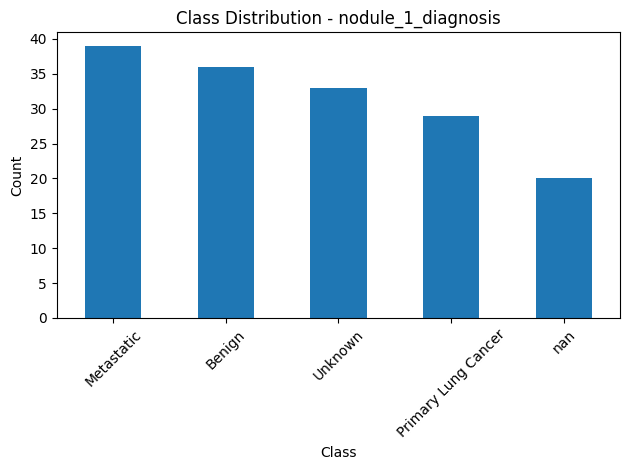

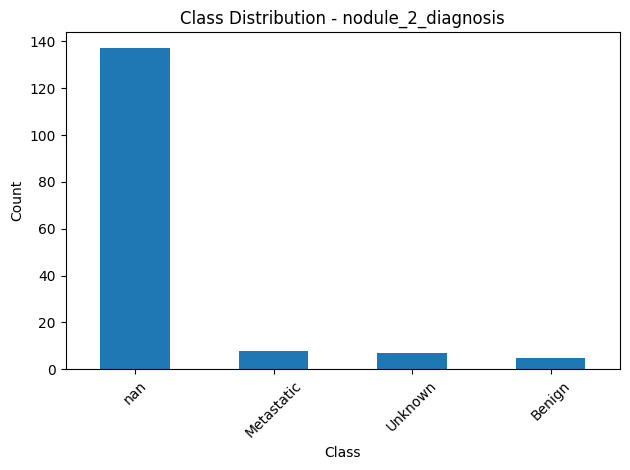

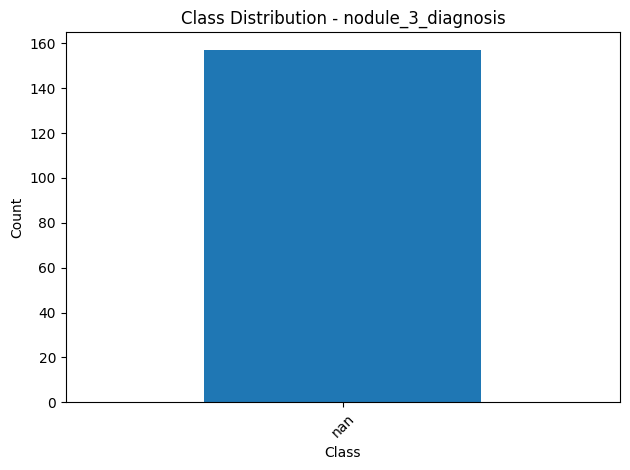

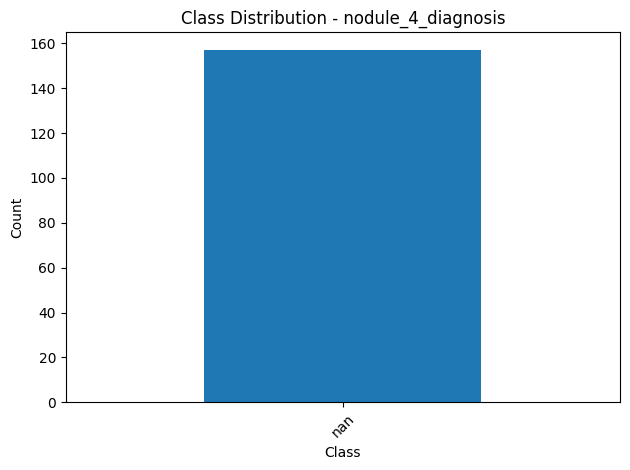

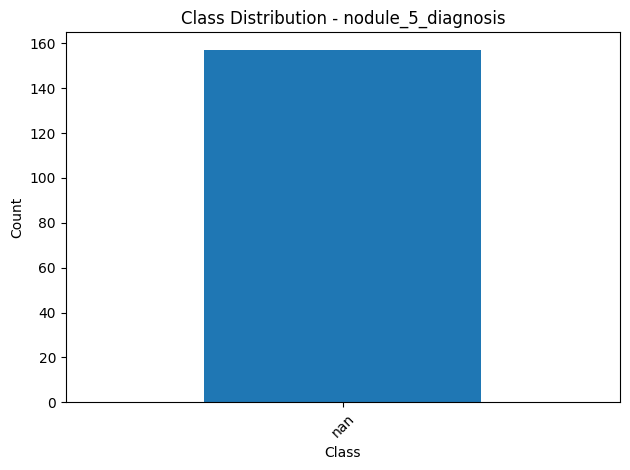

In [11]:
import matplotlib.pyplot as plt

nodule_cols = [f"nodule_{i}_diagnosis" for i in range(1, 6)]

for col in nodule_cols:
    if col in df.columns:
        counts = df[col].map(label_map).value_counts(dropna=False)

        plt.figure()
        counts.plot(kind="bar")

        plt.title(f"Class Distribution - {col}")
        plt.xlabel("Class")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Transforming the dataset to satisfy the tasks:
### T1 — Malignancy

0 if diagnosis == 1  
1 if diagnosis in {2, 3}

### T2 — Progression

0 if method == 1  (stable ≥ 2 years)  
1 if method == 4  (progression)

Filter:
method ∈ {1, 4}

In [15]:
def map_malignancy(x):
    if x in [0,1]:
        return 0  # benign
    elif x in [2, 3]:
        return 1  # malignant
    else:
        return None  # unknown

In [16]:
def map_progression(x):
    if x == 1:
        return 0  # stable
    elif x == 4:
        return 1  # progressive
    else:
        return None

In [17]:
import pandas as pd

processed_rows = []

for i in range(1, 6):
    diag_col = f"nodule_{i}_diagnosis"
    method_col = f"nodule_{i}_diagnosis_method"
    
    if diag_col in df.columns and method_col in df.columns:
        temp = df[["patient_id", diag_col, method_col]].copy()
        
        temp["T1_malignancy"] = temp[diag_col].apply(map_malignancy)
        temp["T2_progression"] = temp[method_col].apply(map_progression)
        
        # Keep only valid progression labels (your filter)
        temp = temp[temp[method_col].isin([1, 4])]
        
        # Drop rows where malignancy is unknown
        temp = temp.dropna(subset=["T1_malignancy", "T2_progression"])
        
        temp["nodule_id"] = i
        
        processed_rows.append(temp)

# Combine all nodules
mtl_df = pd.concat(processed_rows, ignore_index=True)

In [18]:
mtl_df.shape


(64, 14)

In [19]:
mtl_df.head()

,patient_id,nodule_1_diagnosis,nodule_1_diagnosis_method,T1_malignancy,T2_progression,nodule_id,nodule_2_diagnosis,nodule_2_diagnosis_method,nodule_3_diagnosis,nodule_3_diagnosis_method,nodule_4_diagnosis,nodule_4_diagnosis_method,nodule_5_diagnosis,nodule_5_diagnosis_method
0,LIDC-IDRI-0068,3.0,4.0,1.0,1.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LIDC-IDRI-0071,1.0,1.0,0.0,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LIDC-IDRI-0072,1.0,4.0,0.0,1.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIDC-IDRI-0091,3.0,4.0,1.0,1.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LIDC-IDRI-0100,1.0,1.0,0.0,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


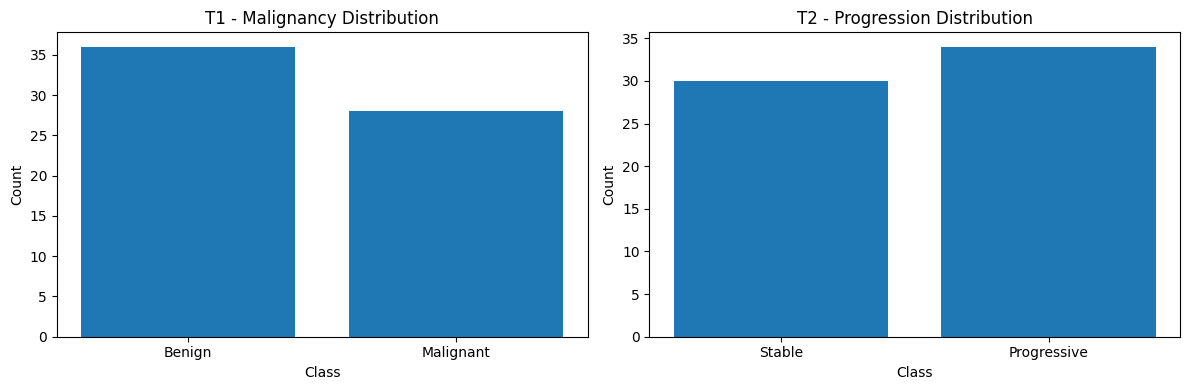

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# T1
t1_counts = mtl_df["T1_malignancy"].value_counts().sort_index()
t1_labels = {0: "Benign", 1: "Malignant"}
axes[0].bar([t1_labels[i] for i in t1_counts.index], t1_counts.values)
axes[0].set_title("T1 - Malignancy Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# T2
t2_counts = mtl_df["T2_progression"].value_counts().sort_index()
t2_labels = {0: "Stable", 1: "Progressive"}
axes[1].bar([t2_labels[i] for i in t2_counts.index], t2_counts.values)
axes[1].set_title("T2 - Progression Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [22]:
mtl_df.to_csv("processed_lung_nodules.csv", index=False)